# 📊 Body Performance Dataset — Exploratory Data Analysis (EDA)
**File 1 of 5 | Diploma Project**

---

## 🎯 Objective
Understand the structure, distributions, correlations and data quality issues
before any modelling is performed.

## 📋 Dataset Overview
| Property | Value |
|----------|-------|
| Rows | 13,393 |
| Columns | 12 (11 features + 1 target) |
| Target | `class` — Performance grade A (Best) → D (Worst) |
| Missing values | None |

## 📂 Columns
| Column | Type | Description |
|--------|------|-------------|
| `age` | int | Age in years (21–64) |
| `gender` | str | Biological sex (M / F) |
| `height_cm` | float | Standing height in cm |
| `weight_kg` | float | Body weight in kg |
| `body fat_%` | float | Body fat % (bioelectrical impedance) |
| `diastolic` | float | Diastolic blood pressure (mmHg) |
| `systolic` | float | Systolic blood pressure (mmHg) |
| `gripForce` | float | Hand-grip dynamometer reading (kg) |
| `sit and bend forward_cm` | float | Sit-and-reach flexibility test (cm) |
| `sit-ups counts` | float | Number of sit-ups completed |
| `broad jump_cm` | float | Standing broad jump distance (cm) |
| `class` | str | **TARGET** — A/B/C/D performance class |


## 🔧 Section 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Colour palette for the 4 performance classes
PALETTE = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}
print("Libraries loaded ✓")


Libraries loaded ✓


## 📥 Section 2 — Load Data & Basic Inspection
Load the raw CSV and print shape, dtypes and the first few rows to get an
initial feel for the data.

In [4]:
df = pd.read_csv("bodyPerformance.csv")

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()


Shape : 13,393 rows × 12 columns

Data Types:
age                          int64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

First 5 rows:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


### Descriptive Statistics
Summary statistics for every numeric column.

In [5]:
df.describe().T.style.background_gradient(cmap="Blues", axis=1)


,count,mean,std,min,25%,50%,75%,max
age,13393.000000,36.775106,13.625639,21.000000,25.000000,32.000000,48.000000,64.000000
height_cm,13393.000000,168.559807,8.426583,125.000000,162.400000,169.200000,174.800000,193.800000
weight_kg,13393.000000,67.447316,11.949666,26.300000,58.200000,67.400000,75.300000,138.100000
body fat_%,13393.000000,23.240165,7.256844,3.000000,18.000000,22.800000,28.000000,78.400000
diastolic,13393.000000,78.796842,10.742033,0.000000,71.000000,79.000000,86.000000,156.200000
systolic,13393.000000,130.234817,14.713954,0.000000,120.000000,130.000000,141.000000,201.000000
gripForce,13393.000000,36.963877,10.624864,0.000000,27.500000,37.900000,45.200000,70.500000
sit and bend forward_cm,13393.000000,15.209268,8.456677,-25.000000,10.900000,16.200000,20.700000,213.000000
sit-ups counts,13393.000000,39.771224,14.276698,0.000000,30.000000,41.000000,50.000000,80.000000
broad jump_cm,13393.000000,190.129627,39.868000,0.000000,162.000000,193.000000,221.000000,303.000000


## 🔍 Section 3 — Missing Values & Duplicates
Check for null values and exact duplicate rows — both will distort model training.

In [6]:
# Missing values per column
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
print(missing[missing > 0] if missing.sum() > 0 else "→ No missing values found ✓")

# Duplicate rows
dup = df.duplicated().sum()
print(f"\nDuplicate rows: {dup}")
if dup > 0:
    print(df[df.duplicated()].to_string())


Total missing values: 0
→ No missing values found ✓

Duplicate rows: 1
       age gender  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm class
12473   27      F      157.0       49.1        30.7       70.0      86.0       27.7                     19.7            51.0          167.0     A


## 🎯 Section 4 — Target Class Distribution
Understand how balanced the four performance classes are.
A balanced dataset (equal class sizes) is ideal for classification.

  Class | Count  | %
  ------+--------+------
    A   | 3,348  | 25.0%
    B   | 3,347  | 25.0%
    C   | 3,349  | 25.0%
    D   | 3,349  | 25.0%


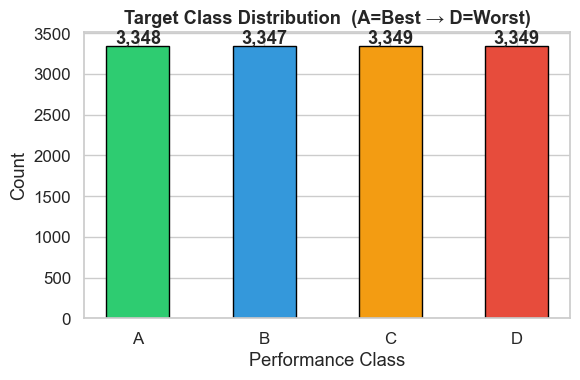

In [7]:
class_counts = df["class"].value_counts().sort_index()
class_pct    = df["class"].value_counts(normalize=True).sort_index() * 100

print("  Class | Count  | %")
print("  ------+--------+------")
for c in class_counts.index:
    print(f"    {c}   | {class_counts[c]:5,}  | {class_pct[c]:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[PALETTE[c] for c in class_counts.index], edgecolor="black", width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f"{val:,}", ha="center", fontweight="bold")
ax.set_title("Target Class Distribution  (A=Best → D=Worst)", fontweight="bold")
ax.set_xlabel("Performance Class"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


## 📈 Section 5 — Univariate Distributions
Histogram + median/mean lines for every numeric feature.
**What to look for:** skewness, multi-modality, extreme outliers.

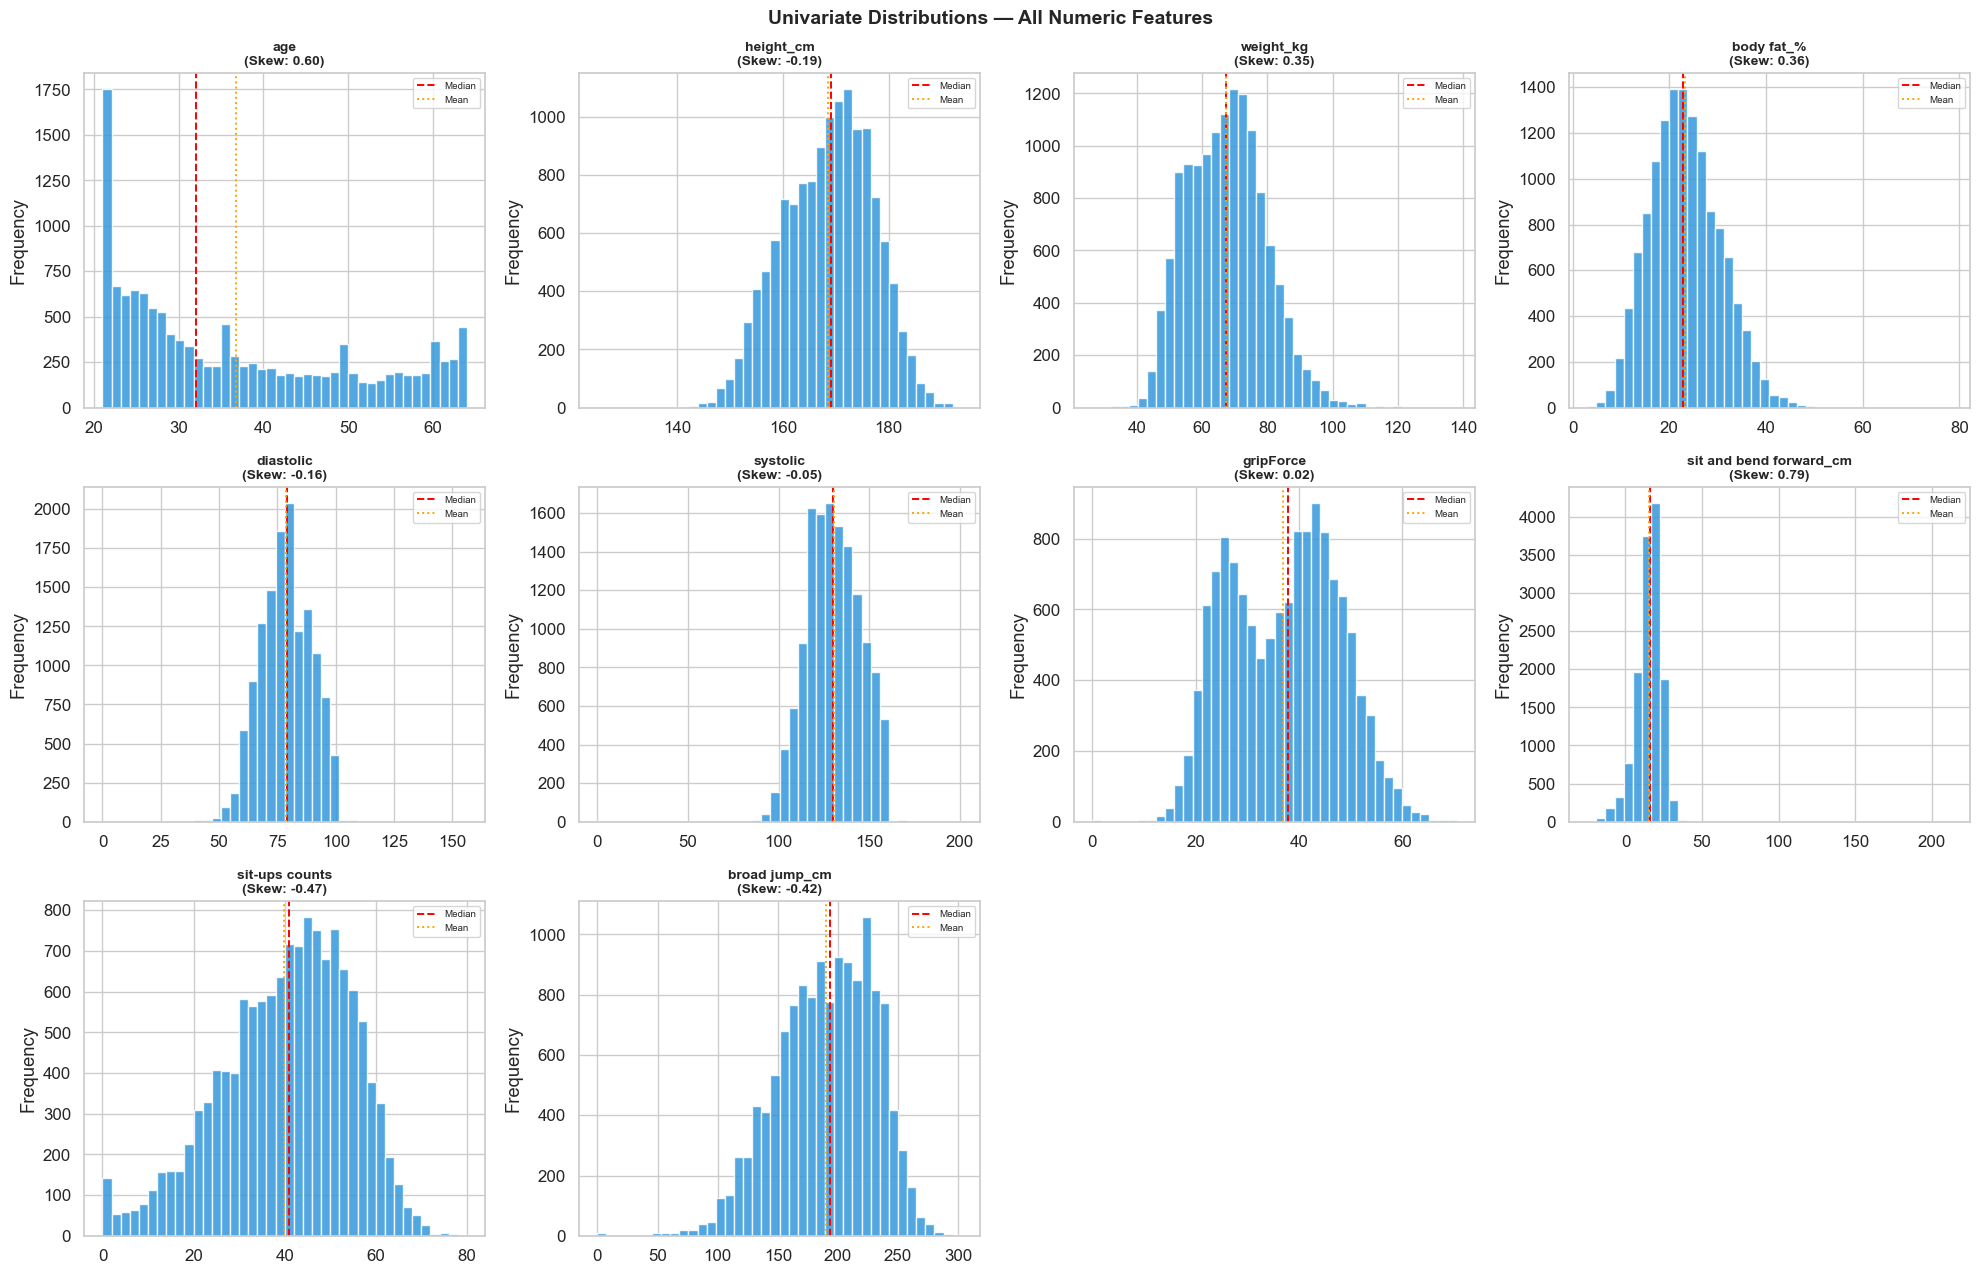

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    skew_val = df[col].skew()
    ax.hist(df[col].dropna(), bins=40, color="#3498db", edgecolor="white", alpha=0.85)
    ax.axvline(df[col].median(), color="red",    linestyle="--", lw=1.4, label="Median")
    ax.axvline(df[col].mean(),   color="orange",  linestyle=":",  lw=1.4, label="Mean")
    ax.set_title(f"{col}\n(Skew: {skew_val:.2f})", fontsize=10, fontweight="bold")
   
    
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Univariate Distributions — All Numeric Features", fontsize=14, fontweight="bold")

plt.tight_layout(); 
plt.show()


## 📦 Section 6 — Feature Distributions by Class (Box Plots)
Box plots split by performance class reveal which features best separate A from D.
**Strong predictors:** features where the boxes barely overlap between classes.

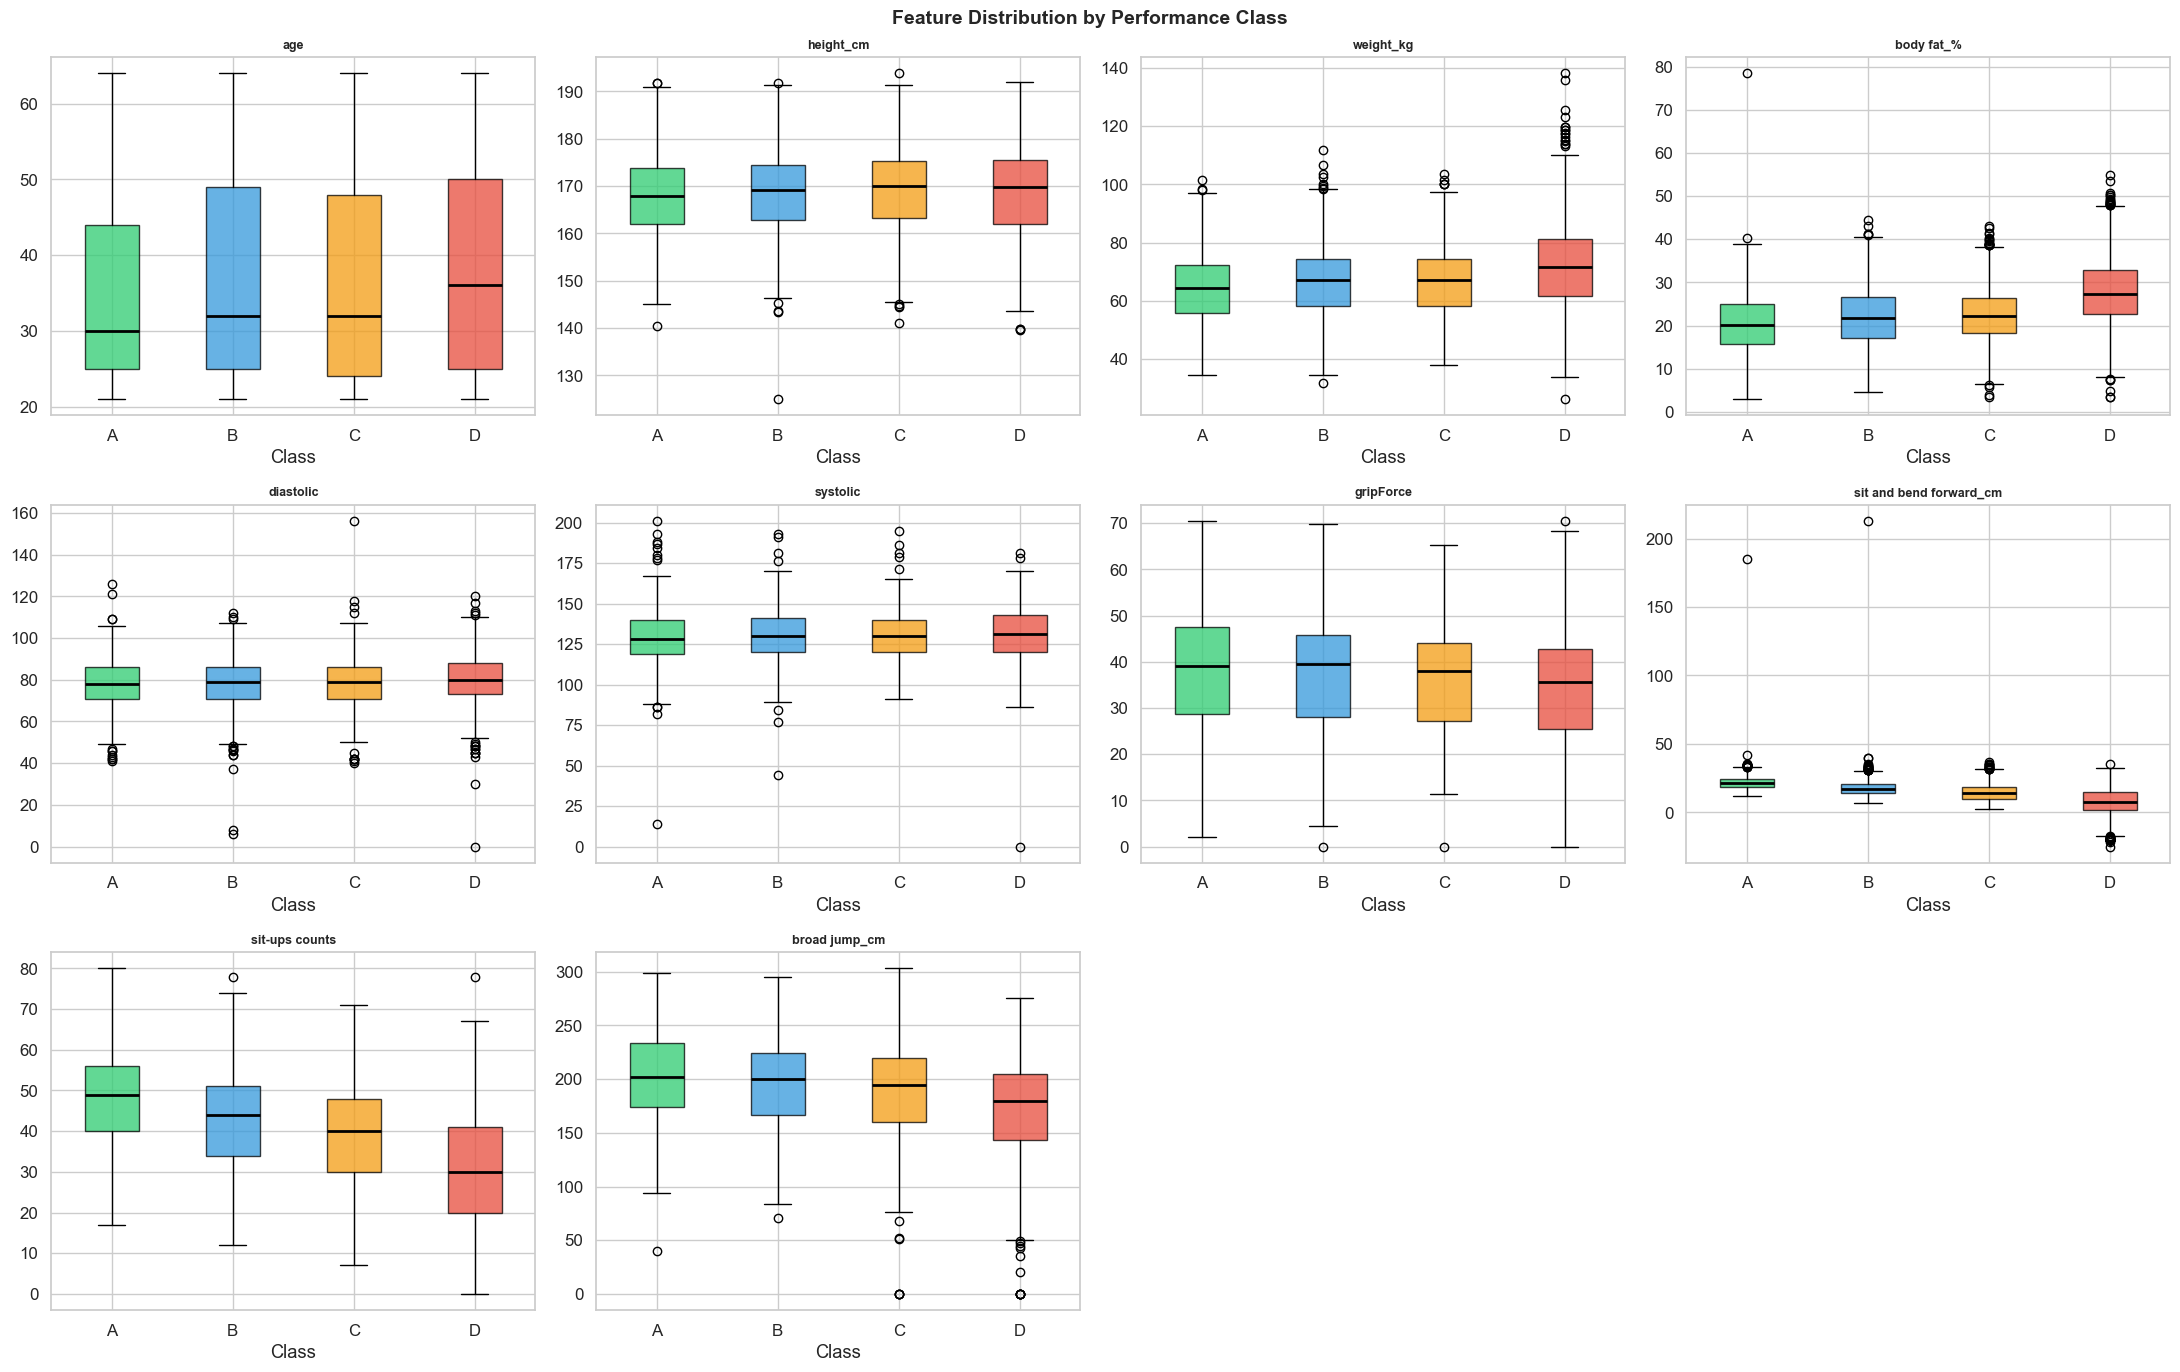

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()
class_order = ["A", "B", "C", "D"]

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data_by_class = [df.loc[df["class"] == c, col].dropna() for c in class_order]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, cls in zip(bp["boxes"], class_order):
        patch.set_facecolor(PALETTE[cls]); patch.set_alpha(0.75)
    ax.set_xticklabels(class_order)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel("Class")

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distribution by Performance Class", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 🔗 Section 7 — Correlation Matrix
Pearson correlation between all numeric features.
**Reading the heatmap:** dark red = strong positive, dark blue = strong negative.
We are especially interested in correlations with `class`.

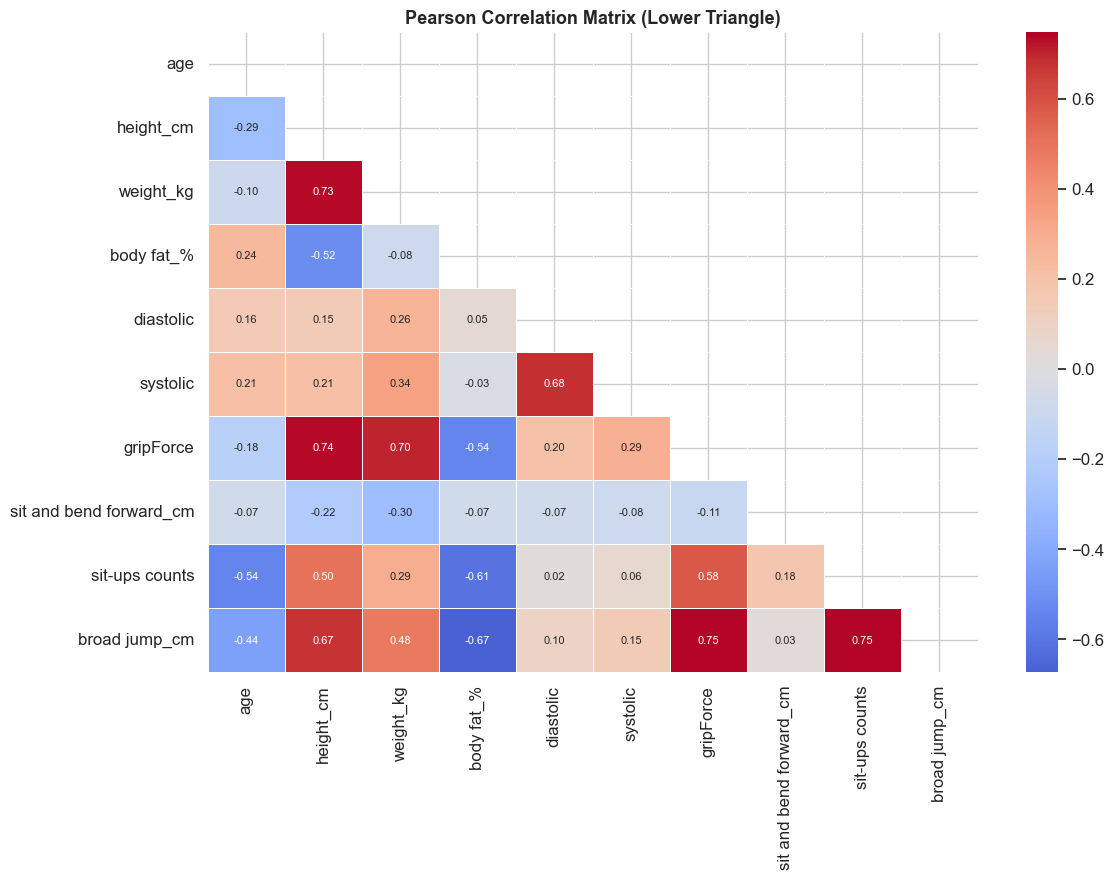


Top 10 absolute correlations:
     Feature A      Feature B  Correlation
 broad jump_cm sit-ups counts     0.748273
 broad jump_cm      gripForce     0.746853
     gripForce      height_cm     0.735024
     weight_kg      height_cm     0.734909
     gripForce      weight_kg     0.700119
      systolic      diastolic     0.676309
 broad jump_cm      height_cm     0.674589
 broad jump_cm     body fat_%    -0.673273
sit-ups counts     body fat_%    -0.608912
sit-ups counts      gripForce     0.576669


In [10]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Pearson Correlation Matrix (Lower Triangle)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Print top correlations
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                   .stack().reset_index())
corr_pairs.columns = ["Feature A", "Feature B", "Correlation"]
print("\nTop 10 absolute correlations:")
print(corr_pairs.reindex(corr_pairs["Correlation"].abs().sort_values(ascending=False).index)
               .head(10).to_string(index=False))


## 👥 Section 8 — Gender Analysis
Examine whether gender distribution differs across performance classes
and how it interacts with grip force.

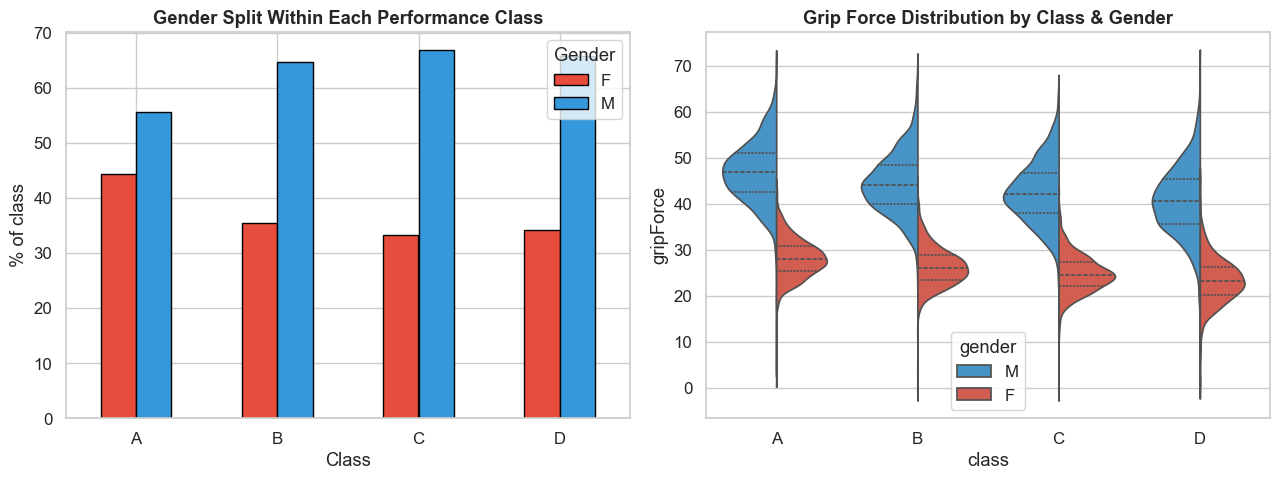

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = pd.crosstab(df["class"], df["gender"], normalize="index") * 100
ct.plot(kind="bar", ax=axes[0], color=["#e74c3c","#3498db"], edgecolor="black", rot=0)
axes[0].set_title("Gender Split Within Each Performance Class", fontweight="bold")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("% of class")
axes[0].legend(title="Gender")

sns.violinplot(data=df, x="class", y="gripForce", hue="gender",
               order=["A","B","C","D"], split=True,
               palette={"M":"#3498db","F":"#e74c3c"}, ax=axes[1], inner="quartile")
axes[1].set_title("Grip Force Distribution by Class & Gender", fontweight="bold")
plt.tight_layout(); plt.show()


## 🔵 Section 9 — Pair Plot (Key Performance Features)
Scatter plot matrix coloured by class for the 5 strongest predictors.
Reveals non-linear cluster separation and which feature pairs best
discriminate the 4 classes.

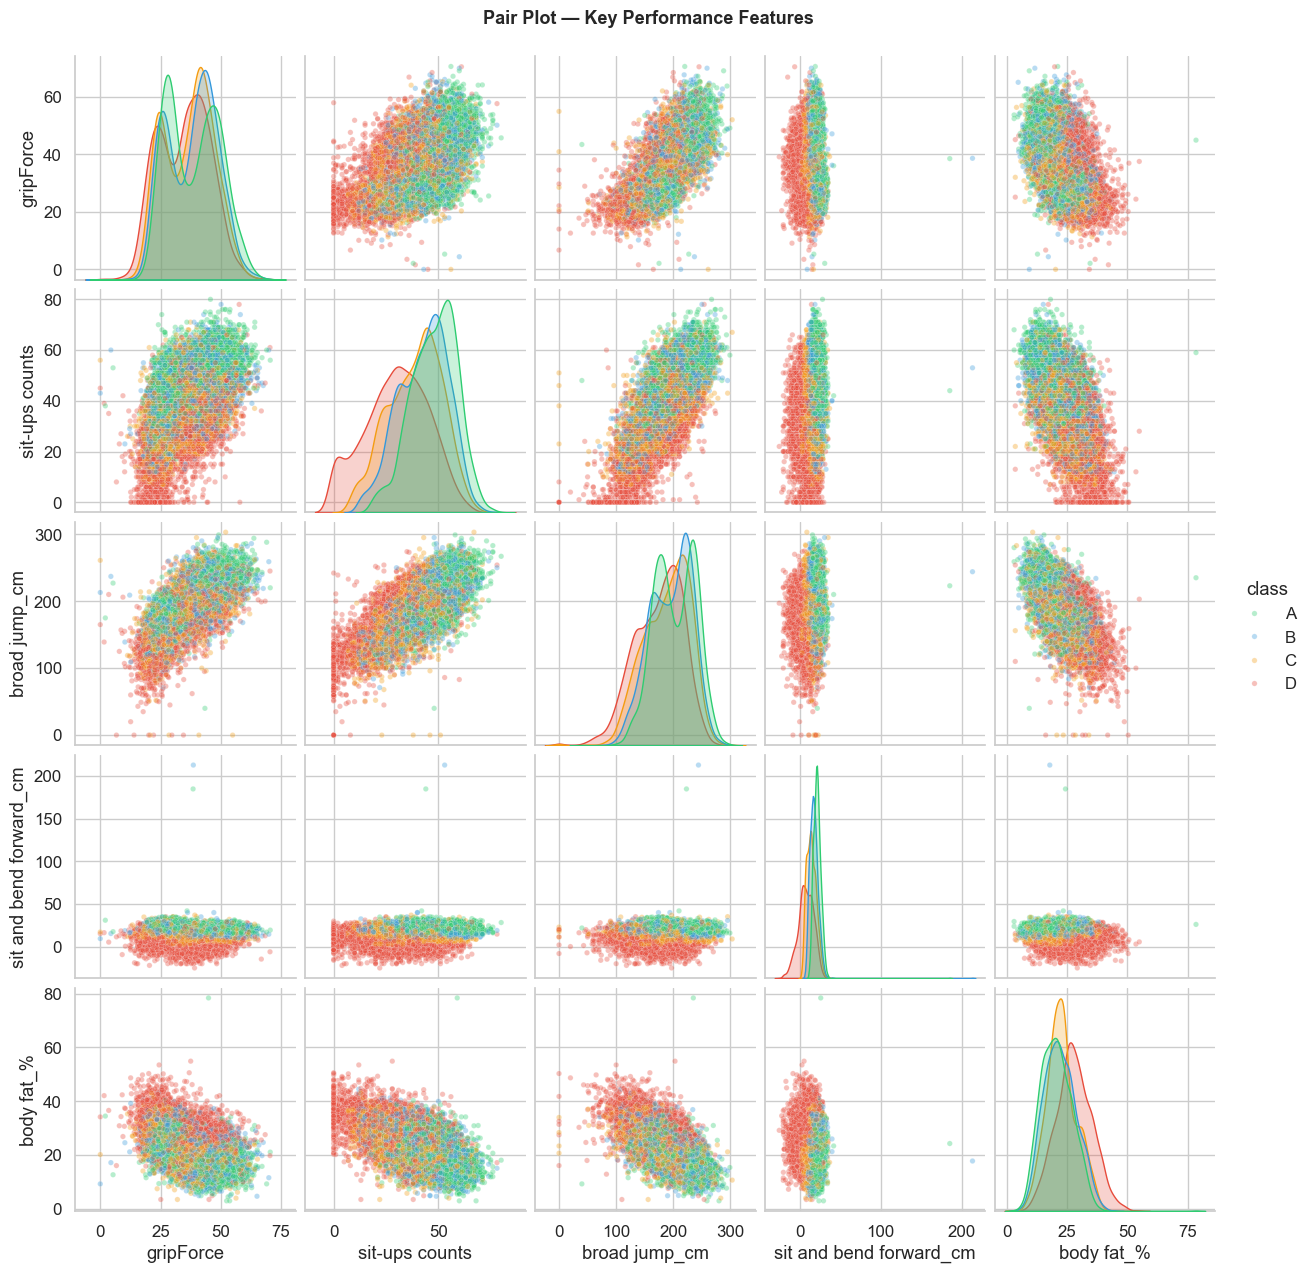

In [13]:
key_features = ["gripForce", "sit-ups counts", "broad jump_cm",
               "sit and bend forward_cm", "body fat_%", "class"]

pg = sns.pairplot(df[key_features], hue="class", palette=PALETTE,
                  diag_kind="kde", plot_kws={"alpha":0.35, "s":15},
                  hue_order=["A","B","C","D"])
pg.fig.suptitle("Pair Plot — Key Performance Features", y=1.02, fontsize=13, fontweight="bold")
plt.show()


## ⚠️ Section 10 — Defect Detection Report
Systematic check of physiological rule violations.
These rows must be fixed before training — they introduce false patterns.

In [39]:
# Initialize tracking
defects = {}
df_remaining = df.copy()  # We will remove rows from this copy step-by-step
initial_count = len(df)

# --- SEQUENCE START ---

# 1. Blood Pressure Logic (Physiologically Impossible)
mask_bp_swap = df_remaining["diastolic"] >= df_remaining["systolic"]
defects["diastolic >= systolic"] = df_remaining[mask_bp_swap]
df_remaining = df_remaining[~mask_bp_swap]

mask_sys_0 = df_remaining["systolic"] == 0
defects["systolic == 0"] = df_remaining[mask_sys_0]
df_remaining = df_remaining[~mask_sys_0]

mask_dia_0 = df_remaining["diastolic"] == 0
defects["diastolic == 0"] = df_remaining[mask_dia_0]
df_remaining = df_remaining[~mask_dia_0]

# 2. Extreme Medical Outliers
# Anything > 190 is medically extreme for a performance test environment
mask_sys_high = df_remaining["systolic"] > 190
defects["systolic > 190"] = df_remaining[mask_sys_high]
df_remaining = df_remaining[~mask_sys_high]

mask_dia_high = df_remaining["diastolic"] > 120
defects["diastolic > 120"] = df_remaining[mask_dia_high]
df_remaining = df_remaining[~mask_dia_high]

mask_fat = df_remaining["body fat_%"] > 60
defects["body fat_% > 60"] = df_remaining[mask_fat]
df_remaining = df_remaining[~mask_fat]

# 3. Anthropometric Defects
mask_height = df_remaining["height_cm"] < 140
defects["height_cm < 140"] = df_remaining[mask_height]
df_remaining = df_remaining[~mask_height]

mask_weight = df_remaining["weight_kg"] < 30
defects["weight_kg < 30"] = df_remaining[mask_weight]
df_remaining = df_remaining[~mask_weight]

# 4. Flexibility Test Boundaries
mask_flex_high = df_remaining["sit and bend forward_cm"] > 45
defects["flexibility > 45"] = df_remaining[mask_flex_high]
df_remaining = df_remaining[~mask_flex_high]

mask_flex_low = df_remaining["sit and bend forward_cm"] < -15
defects["flexibility < -15"] = df_remaining[mask_flex_low]
df_remaining = df_remaining[~mask_flex_low]

# 5. Logical BMI & Body Composition Errors
# (Calculating BMI only on the remaining valid height/weight rows)
df_remaining["BMI_raw"] = df_remaining["weight_kg"] / (df_remaining["height_cm"]/100)**2

mask_bmi_low = df_remaining["BMI_raw"] < 17
defects["BMI < 17"] = df_remaining[mask_bmi_low]
df_remaining = df_remaining[~mask_bmi_low]

mask_tall_thin = (df_remaining["height_cm"] > 165) & (df_remaining["weight_kg"] < 40) & (df_remaining["age"] > 20)
defects["Tall+thin (h>165,w<40,age>20)"] = df_remaining[mask_tall_thin]
df_remaining = df_remaining[~mask_tall_thin]

# 6. Broad Jump Outliers (World-class elite limit)
mask_jump_low = df_remaining["broad jump_cm"] < 25
defects["broad jump < 25cm"] = df_remaining[mask_jump_low]
# Action: We use CLIP instead of DROP to keep the row but fix the typo
df_remaining["broad jump_cm"] = df_remaining["broad jump_cm"].clip(lower=25)

# 7. Sit-ups Logic: General Outliers & Class Contradictions
# Identify logical contradictions (Elite score in lowest class)
# Note: Use "D" if classes are still strings, or 0 if you already mapped them to numbers.
mask_situps_contradiction = (df_remaining["sit-ups counts"] > 70) & (df_remaining["class"] == 'D')
defects["sit-ups > 70 and class D"] = df_remaining[mask_situps_contradiction]

# Action: Drop contradictions because the data point is untrustworthy
df_remaining = df_remaining[~mask_situps_contradiction]

# --- SEQUENCE END ---

# Print Summary Table
print(f"{'Sequential Issue Filter':<40} {'Removed':>7}")
print("─" * 50)
total_removed = 0
for issue, rows in defects.items():
    count = len(rows)
    total_removed += count
    print(f"{issue:<40} {count:>7}")

print("─" * 50)
print(f"Total rows removed from dataset : {total_removed:,}")
print(f"Final clean dataset rows        : {len(df_remaining):,}")
print(f"Data Loss Percentage            : {(total_removed/initial_count)*100:.2f}%")

Sequential Issue Filter                  Removed
──────────────────────────────────────────────────
diastolic >= systolic                          5
systolic == 0                                  0
diastolic == 0                                 0
systolic > 190                                 5
diastolic > 120                                1
body fat_% > 60                                1
height_cm < 140                                4
weight_kg < 30                                 1
flexibility > 45                               2
flexibility < -15                             38
BMI < 17                                      47
Tall+thin (h>165,w<40,age>20)                  0
broad jump < 25cm                             10
sit-ups > 70 and class D                       1
──────────────────────────────────────────────────
Total rows removed from dataset : 115
Final clean dataset rows        : 13,288
Data Loss Percentage            : 0.86%


In [25]:
defects = {}

# Rule 1: diastolic must be < systolic (basic physiology)
defects["diastolic >= systolic"]      = df[df["diastolic"] >= df["systolic"]]
defects["systolic == 0"]              = df[df["systolic"]  == 0]
defects["diastolic == 0"]             = df[df["diastolic"] == 0]
defects["systolic > 200"]             = df[df["systolic"]  > 200]
defects["diastolic > 120"]            = df[df["diastolic"] > 120]
defects["body fat_% > 60"]            = df[df["body fat_%"] > 60]
defects["height_cm < 140"]            = df[df["height_cm"] < 140]
defects["weight_kg < 30"]             = df[df["weight_kg"] < 30]
defects["flexibility > 45"]           = df[df["sit and bend forward_cm"] > 45]
defects["flexibility < -25"]          = df[df["sit and bend forward_cm"] < -15]

_df = df.copy()
_df["BMI_raw"] = _df["weight_kg"] / (_df["height_cm"]/100)**2
defects["BMI < 17"]                   = _df[_df["BMI_raw"] < 17]
defects["Tall+thin (h>165,w<40,age>20)"] = df[(df["height_cm"]>165) & (df["weight_kg"]<40) & (df["age"]>20)]

total = set()
print(f"{'Issue':<40} {'Count':>7}")
print("─" * 50)
for issue, rows in defects.items():
    total.update(rows.index.tolist())
    print(f"{issue:<40} {len(rows):>7}")
print("─" * 50)
print(f"Total unique defective rows : {len(total):,}  ({len(total)/len(df)*100:.2f}%)")


Issue                                      Count
──────────────────────────────────────────────────
diastolic >= systolic                          5
systolic == 0                                  1
diastolic == 0                                 1
systolic > 200                                 1
diastolic > 120                                3
body fat_% > 60                                1
height_cm < 140                                4
weight_kg < 30                                 1
flexibility > 45                               2
flexibility < -25                             38
BMI < 17                                      49
Tall+thin (h>165,w<40,age>20)                  1
──────────────────────────────────────────────────
Total unique defective rows : 100  (0.75%)


## 📏 Section 11 — IQR Outlier Summary
Statistical outlier count per feature using the 1.5×IQR rule.

In [23]:
print(f"{'Feature':<32} {'Q1':>7} {'Q3':>7} {'Lower':>8} {'Upper':>8} {'#Out':>7}")
print("─" * 72)
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:<32} {q1:>7.2f} {q3:>7.2f} {lo:>8.2f} {hi:>8.2f} {n_out:>7,}")

print("\n✅ EDA complete — proceed to 02_Preprocessing.ipynb")


Feature                               Q1      Q3    Lower    Upper    #Out
────────────────────────────────────────────────────────────────────────
age                                25.00   48.00    -9.50    82.50       0
height_cm                         162.40  174.80   143.80   193.40      10
weight_kg                          58.20   75.30    32.55   100.95      83
body fat_%                         18.00   28.00     3.00    43.00      77
diastolic                          71.00   86.00    48.50   108.50      54
systolic                          120.00  141.00    88.50   172.50      29
gripForce                          27.50   45.20     0.95    71.75       3
sit and bend forward_cm            10.90   20.70    -3.80    35.40     409
sit-ups counts                     30.00   50.00     0.00    80.00       0
broad jump_cm                     162.00  221.00    73.50   309.50      57

✅ EDA complete — proceed to 02_Preprocessing.ipynb
